# Proyecto final integrador — Fase 4

## Sobreduración en la titulación de la educación superior chilena: del registro administrativo al hallazgo comunicado

Programación para la Ciencia de Datos (202682.1927) · Magíster en Ciencia de Datos e
Inteligencia Artificial · Universidad Andrés Bello · Sebastian Antunez Noguera

---

### Cómo está organizado

Este cuaderno consolida las cuatro fases en un solo documento. No repite el trabajo
anterior: lo **invoca** y lo somete a verificación. El pipeline de limpieza es el de la
Fase 2 (`src/pipeline.py`); los algoritmos, las métricas y los modelos son los de la
Fase 3 (`src/nucleo/`).

| Sección | Contenido |
|---|---|
| I | Fase 1 — el problema, la pregunta y los objetivos |
| II | Fase 2 — el conjunto preparado y sus decisiones |
| III | Fase 3 — el núcleo algorítmico, su validación y su eficiencia |
| IV | Fase 4 — recuperar la interpretabilidad para poder visualizar |
| V | Exploración dirigida por los objetivos |
| VI | Las tres figuras del informe |
| VII | El relato de los hallazgos |
| VIII | Resultados, discusión y conclusiones |
| IX | Trazabilidad de mejoras |
| X | Exportación y verificación final |

### Cómo leerlo

Cada figura va acompañada de cuatro enunciados —qué muestra, qué infiero, qué límite
tiene y cómo aporta al relato— porque una figura sin lectura declarada obliga a quien
evalúa a adivinar qué se afirma con ella.

### Cómo ejecutarlo

*Kernel → Restart Kernel and Run All Cells*. Toma alrededor de un minuto con el dataset
completo. Si el Parquet de la Fase 2 no existe, la fachada degrada a la muestra
versionada de 5.000 registros y lo informa.

## Entorno y reproducibilidad

La reproducibilidad es una propiedad del conjunto: basta una dependencia sin versión
para perderla. Esta celda deja constancia de las versiones exactas con las que se
generaron los resultados y verifica que coincidan con las declaradas.

In [1]:
# Celda de arranque: hace importable el paquete `src` sin instalar el proyecto
# y funciona igual si el notebook se abre desde la raiz o desde su subcarpeta.
import sys
from pathlib import Path

RAIZ = Path.cwd()
if not (RAIZ / "src").exists():
    RAIZ = RAIZ.parent
sys.path.insert(0, str(RAIZ))

import pandas as pd

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)

from src import config

print("Raiz del proyecto:", RAIZ)
for clave, valor in config.describir_entorno().items():
    print(f"  {clave:12s} {valor}")

Raiz del proyecto: D:\Magister Ciencia de Datos\Programacion para la Ciencia\Sumativas\proyecto-titulados


  python       3.14.7
  plataforma   Windows-11-10.0.26200-SP0
  ejecutable   D:\Magister Ciencia de Datos\Programacion para la Ciencia\Sumativas\proyecto-titulados\.venv\Scripts\python.exe
  numpy        2.5.3
  pandas       3.0.5
  matplotlib   3.11.1
  seaborn      0.13.2
  pyarrow      25.0.1


In [2]:
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.nucleo.fachada import NucleoAnalitico

INICIO = time.perf_counter()
SEMILLA = 42

# Estilo y paleta con funcion: un color dirige la mirada, el otro es contexto.
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 150,
    "savefig.bbox": "tight",
    "axes.titleweight": "bold",
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "font.size": 10,
    "legend.frameon": False,
})
DESTACADO = "#AC212E"   # aquello sobre lo que se dirige la mirada
NEUTRO    = "#9FB6C8"   # el contexto
APOYO     = "#2C5F8D"   # segunda serie cuando hay comparacion

nucleo = NucleoAnalitico(limite_cohorte=300_000, semilla=SEMILLA)
df = nucleo.datos

print(f"Origen de los datos: {nucleo.origen_datos}")
print(f"Registros: {len(df):,} | columnas: {df.shape[1]}".replace(",", "."))
print(f"Periodo cubierto: {int(df['anio_titulo'].min())}-{int(df['anio_titulo'].max())}")

Origen de los datos: completo
Registros: 1.246.760 | columnas: 47
Periodo cubierto: 2020-2026


In [3]:
import importlib.metadata as meta

requeridas = {}
for linea in (RAIZ / "requirements.txt").read_text(encoding="utf-8").splitlines():
    linea = linea.split("#")[0].strip()
    if "==" in linea:
        nombre, version = linea.split("==")
        requeridas[nombre.strip()] = version.strip()

filas = []
for paquete, esperada in requeridas.items():
    try:
        instalada = meta.version(paquete)
    except meta.PackageNotFoundError:
        instalada = "NO INSTALADO"
    filas.append({"paquete": paquete, "requerida": esperada,
                  "instalada": instalada, "coincide": instalada == esperada})

entorno = pd.DataFrame(filas)
print(entorno.to_string(index=False))
print(f"\nPython {sys.version.split()[0]}")
print(f"Dependencias que coinciden: {entorno['coincide'].sum()} de {len(entorno)}")
assert entorno["coincide"].all(), "hay dependencias con version distinta a la declarada"

   paquete requerida instalada  coincide
     numpy     2.5.3     2.5.3      True
    pandas     3.0.5     3.0.5      True
   pyarrow    25.0.1    25.0.1      True
matplotlib    3.11.1    3.11.1      True
   seaborn    0.13.2    0.13.2      True
jupyterlab     4.6.3     4.6.3      True
  notebook     7.6.2     7.6.2      True
 ipykernel     7.3.0     7.3.0      True
  nbformat    5.11.1    5.11.1      True
 nbconvert    7.17.1    7.17.1      True
    pytest     9.1.1     9.1.1      True

Python 3.14.7
Dependencias que coinciden: 11 de 11


# I. Fase 1 — El problema y los objetivos

## 1.1 Contexto y problema

El sistema de educación superior chileno declara, para cada carrera, una **duración
teórica**: los semestres que el plan compromete con el estudiante. Esa cifra orienta
decisiones concretas —cuánto financiamiento pedir, cuántos años de arancel prever— y
sobre ella se calculan la duración de las becas y los créditos estatales.

El sistema **no publica** cuánto tardan efectivamente los estudiantes. La diferencia
entre ambas magnitudes no existe como variable en ningún registro oficial.

**A quién sirve el resultado.** A quien diseña programas de acompañamiento en una
institución, que necesita saber dónde concentrar recursos; y a quien revisa la duración
declarada de un plan de estudios, que necesita saber si esa declaración describe la
trayectoria real o una que casi nadie cumple.

## 1.2 Pregunta que guía el proyecto

> ¿Es posible reconstruir la duración real de la titulación a partir de los registros
> administrativos disponibles y, con esa variable derivada, caracterizar la magnitud y
> la distribución del rezago en la educación superior chilena?

## 1.3 Objetivos

**Objetivo general.** Construir, validar y analizar un indicador de sobreduración en la
titulación de pregrado en Chile a partir de los registros del SIES 2020-2025, mediante
un desarrollo en Python íntegramente reproducible y versionado.

**Objetivos específicos.** Los tres primeros son instrumentales: producen el
instrumento. Los tres últimos son analíticos y **cada uno tiene su figura** en la
sección VI.

| # | Objetivo específico | Tipo | Evidencia |
|---|---|---|---|
| OE1 | Consolidar los seis archivos anuales en un conjunto analítico validado | Instrumental | Sección II |
| OE2 | Reconstruir la duración real y derivar la sobreduración | Instrumental | Sección II |
| OE3 | Implementar el núcleo algorítmico y medir su eficiencia | Instrumental | Sección III |
| **OE4** | **Dimensionar la magnitud del rezago en el sistema** | Analítico | **Figura 1** |
| **OE5** | **Identificar qué factores se asocian a mayor rezago** | Analítico | **Figura 2** |
| **OE6** | **Caracterizar la evolución temporal y delimitar su lectura** | Analítico | **Figura 3** |

## 1.4 Alcance, restricciones y supuestos

Son tres categorías distintas y conviene no mezclarlas.

**Alcance** — qué se aborda y qué no.

| Dimensión | Definición adoptada |
|---|---|
| Población | Titulados de pregrado del sistema chileno |
| Período | Procesos de titulación 2020-2025, más el parcial 2026-S1 |
| Unidad de análisis | El proceso de titulación, no la persona |
| Fuera de alcance | Deserción, rendimiento académico, costo monetario |

**Restricciones** — límites impuestos por los datos o el acceso.

- La base registra únicamente titulados: quien abandonó no aparece.
- El semestre de titulación se deriva del mes, porque la fuente no lo entrega.
- Las duraciones teóricas las reporta cada institución y no están auditadas.
- Los CSV originales (955 MB) no se versionan; se distribuye una muestra de 5.000 filas.

**Supuestos** — condiciones bajo las cuales los resultados son interpretables.

- La trayectoria entre ingreso y titulación se supone continua: un semestre congelado se
  contabiliza como tiempo transcurrido.
- El año y semestre de ingreso a la carrera de origen identifican el inicio de la
  trayectoria conducente al título obtenido.
- La duración teórica declarada es la vigente para la cohorte del estudiante.

## 1.5 Cómo cada fase contribuye

| Fase | Aporte | Sin ella no sería posible |
|---|---|---|
| F1 | Entorno reproducible y código modular | Que el proyecto creciera de 5 a 16 módulos sin reescrituras |
| F2 | Conjunto analítico validado y variable objetivo derivada | Ninguna de las figuras de este cuaderno |
| F3 | Algoritmos propios verificados, POO y modelos | Contrastar la cota teórica con la medición real |
| F4 | Interpretabilidad, figuras y relato | Que un tercero comprenda el hallazgo |

# II. Fase 2 — El conjunto preparado

## 2.1 Decisiones de preparación y su justificación

El punto de partida fueron seis CSV del SIES: 955 MB, 1.710.167 filas, 40 columnas.

El hallazgo que definió el proyecto apareció al leer el diccionario de variables: las
columnas `dur_estudio_carr`, `dur_proceso_tit` y `dur_total_carr` **no** registran lo que
el estudiante tardó, sino lo que el plan declara. Son un atributo de la carrera, no de la
persona. La duración real hubo que reconstruirla:

```python
semestre_titulo   = np.where(mes_titulo <= 7, 1, 2)
duracion_real_sem = (anio_titulo - anio_ing_carr_ori) * 2 \
                    + (semestre_titulo - sem_ing_carr_ori) + 1
sobreduracion_sem = duracion_real_sem - dur_total_carr
```

El «+1» no es un ajuste arbitrario: quien ingresa y se titula en el mismo semestre cursó
un semestre, no cero.

In [4]:
pipeline = pd.DataFrame([
    ("1. Ingesta", "Lectura por bloques de 6 CSV con dtypes declarados",
     "1.710.167 filas", "Declarar tipos evita inferencias erroneas y reduce memoria"),
    ("2. Centinelas", "9995/9998/9999/1900, 19000101 y semestre 0 a nulos",
     "62.492 en ano de ingreso", "Como numeros producirian duraciones imposibles"),
    ("3. Normalizacion", "18 categoricas homogeneizadas sobre su catalogo",
     "8,6 millones de celdas", "Evita categorias duplicadas por capitalizacion"),
    ("4. Pregrado", "Filtro nivel_global == Pregrado",
     "398.391 excluidos", "Posgrado no es comparable en duracion teorica"),
    ("5. Duplicados", "Clave estudiante + carrera + fecha",
     "72 eliminados", "Dos nulos no deben tratarse como iguales"),
    ("6. Sin insumos", "Filas sin ano o semestre de ingreso utilizable",
     "61.825 (4,7 %)", "Imputar el inicio equivaldria a inventar la variable objetivo"),
    ("7. Derivacion", "Duracion real, sobreduracion, indice, edad, categoria",
     f"{len(df):,} finales".replace(",", "."), "Enteros exactos: sin error de redondeo"),
    ("8. Atipicos", "Fuera de [1, 40] semestres o edad fuera de [15, 90]",
     "3.119 (0,25 %) marcados", "Marcar en vez de eliminar deja la decision reversible"),
], columns=["Paso", "Tratamiento", "Efecto", "Justificacion tecnica"])

print(pipeline.to_string(index=False, max_colwidth=44))
print(f"\nRetencion: {len(df):,} de 1.710.167 filas ({100*len(df)/1_710_167:.1f} %)".replace(",", "."))

            Paso                                  Tratamiento                   Efecto                        Justificacion tecnica
      1. Ingesta Lectura por bloques de 6 CSV con dtypes d...          1.710.167 filas Declarar tipos evita inferencias erroneas...
   2. Centinelas 9995/9998/9999/1900, 19000101 y semestre ... 62.492 en ano de ingreso Como numeros producirian duraciones impos...
3. Normalizacion 18 categoricas homogeneizadas sobre su ca...   8,6 millones de celdas Evita categorias duplicadas por capitaliz...
     4. Pregrado              Filtro nivel_global == Pregrado        398.391 excluidos Posgrado no es comparable en duracion teo...
   5. Duplicados           Clave estudiante + carrera + fecha            72 eliminados     Dos nulos no deben tratarse como iguales
  6. Sin insumos Filas sin ano o semestre de ingreso utili...           61.825 (4,7 %) Imputar el inicio equivaldria a inventar ...
   7. Derivacion Duracion real, sobreduracion, indice, eda...        1.246.7

## 2.2 Lo que la Fase 3 recibió y entregó

La Fase 3 recibió este conjunto validado y devolvió tres cosas que la Fase 4 utiliza: los
algoritmos verificados con sus mediciones de eficiencia, el modelo de dominio orientado a
objetos, y los parámetros de las transformaciones —que son los que permiten **revertir**
el escalamiento en la sección IV.

# III. Fase 3 — El núcleo algorítmico

## 3.1 Validación técnica

Tres niveles de verificación, todos ejecutables. Primero las reglas de coherencia del
dominio, que reutilizan sin modificación el motor de reglas escrito en la Fase 2.

In [5]:
from src.nucleo.validacion_f3 import validador_nucleo

resultado = nucleo.ajustar_modelos(limite=200_000, iteraciones=1500, tasa=0.5)
X_ent, X_pru, *_ = nucleo.preparar_modelacion(200_000)

contexto = {"df": df, "cohorte": nucleo.cohorte, "arbol": nucleo.jerarquia,
            "resultado": resultado, "X_ent": X_ent, "X_pru": X_pru}
reporte = validador_nucleo().ejecutar(contexto)
print(reporte[["regla", "descripcion", "estado"]].to_string(index=False, max_colwidth=58))

aprobadas = (reporte["estado"] == "PASA").sum()
print("\nReglas aprobadas:", aprobadas, "de", len(reporte))
assert not (reporte["estado"] == "FALLA").any(), "hay reglas criticas sin cumplir"

                  regla                                                descripcion estado
        cohorte_y_arbol La jerarquia contiene exactamente los titulados de la c...   PASA
      hojas_suman_total Las hojas del arbol suman el total de la raiz (recursio...   PASA
      metrica_composite Una metrica via el arbol coincide con la misma via la c...   PASA
tasa_oportuna_coherente La tasa de titulacion oportuna sobre objetos coincide c...   PASA
        convergencia_gd   El descenso de gradiente converge a la solucion cerrada.   PASA
        perdida_decrece                  La perdida final es menor que la inicial.   PASA
    matrices_modelacion           Las matrices no tienen NaN y comparten columnas.   PASA
       metricas_finitas       Todas las metricas de desempeno son numeros finitos.   PASA
            r2_positivo El modelo lineal explica varianza en el conjunto de pru...   PASA

Reglas aprobadas: 9 de 9


In [6]:
import subprocess

interprete = RAIZ / ".venv" / "Scripts" / "python.exe"
if not interprete.exists():
    interprete = Path(sys.executable)

proceso = subprocess.run([str(interprete), "-m", "pytest", "tests/", "-q", "--tb=short"],
                         cwd=RAIZ, capture_output=True, text=True,
                         encoding="utf-8", errors="replace")
print(f"Interprete: {interprete}\n")
print(proceso.stdout[-1200:])
if proceso.returncode != 0:
    print("--- stderr ---\n", proceso.stderr[-1500:])
assert proceso.returncode == 0, "las pruebas automatizadas no pasaron"

Interprete: D:\Magister Ciencia de Datos\Programacion para la Ciencia\Sumativas\proyecto-titulados\.venv\Scripts\python.exe

........................................................................ [ 98%]
.                                                                        [100%]
73 passed in 1.87s



## 3.2 Medición de eficiencia

Las mediciones se hicieron con `timeit` (mínimo de las repeticiones, porque el ruido del
sistema solo puede sumar tiempo) y `tracemalloc` (pico de asignación). Se recuperan aquí
para el reporte final sin repetir un proceso de varios minutos.

In [7]:
eficiencia = pd.read_csv(RAIZ / "reports" / "tables" / "f3_comparacion_implementaciones.csv")
exponentes = pd.read_csv(RAIZ / "reports" / "tables" / "f3_exponentes_empiricos.csv")

print("--- Tiempo y memoria por implementacion (n = 200.000) ---")
print(eficiencia[["operacion", "implementacion", "segundos",
                  "memoria_pico_kb", "razon_vs_mejor"]].to_string(index=False))
print("\n--- Cota teorica frente a exponente empirico ---")
print(exponentes.to_string(index=False))

--- Tiempo y memoria por implementacion (n = 200.000) ---
   operacion               implementacion  segundos  memoria_pico_kb  razon_vs_mejor
  agregación           agrupar_media O(n)  0.047951              0.7             5.7
  agregación agrupar_media_ingenua O(n·k)  0.086007            705.5            10.2
  agregación               pandas groupby  0.008428           3132.6             1.0
ordenamiento                   numpy.sort  0.008656           3127.8             1.0
ordenamiento        sorted (Timsort en C)  0.011938           2343.6             1.4
ordenamiento     ordenar_merge O(n log n)  0.589112           3250.9            68.1
     mediana                 numpy.median  0.009415           3128.2             1.0
     mediana mediana_ordenando O(n log n)  0.012098           2343.6             1.3
     mediana             quickselect O(n)  0.052795           4422.2             5.6
    búsqueda    busqueda_binaria O(log n)  0.000001              0.0             1.0
    bús

Las mediciones respaldan tres decisiones que están implementadas en el código:

1. La agregación de una sola pasada O(n) reemplazó a la ingenua O(n·k): **1,9 veces más
   rápida** y **860 veces más económica en memoria** (0,7 KB frente a 603,9 KB).
2. Los conteos por umbral usan dos búsquedas binarias sobre una copia ordenada:
   **6.516 veces más rápido** que el recorrido lineal.
3. pandas y NumPy se conservan para lo masivo, porque a igual complejidad su constante es
   uno o dos órdenes de magnitud menor.

Una excepción resultó instructiva: `quickselect` es O(n) en comparaciones pero su
exponente empírico es **1,22**, porque cada nivel de recursión asigna tres listas nuevas.
La cota describe el crecimiento, no la constante ni el costo de la memoria.

# IV. Fase 4 — Recuperar la interpretabilidad

El conjunto que produce un pipeline está optimizado para el cálculo, no para la lectura
humana. Dos transformaciones lo vuelven ilegible: el **escalamiento** quita las unidades
—un valor de −0,43 no significa nada— y la **codificación one-hot** disuelve la categoría
en columnas de ceros y unos.

La consecuencia práctica es que un proyecto necesita **dos versiones** del conjunto: la
matriz transformada para el análisis, y una copia interpretable para las figuras. Ninguna
es más correcta que la otra; sirven a propósitos distintos.

In [8]:
# --- Como llegan las variables desde el pipeline de modelacion -------------
from src.nucleo.fachada import VARIABLES_CATEGORICAS, VARIABLES_NUMERICAS

print("Matriz de modelacion (lo que consumen los modelos):")
print(f"  forma: {X_ent.shape} | columnas: {len(resultado.columnas)}")
print(f"  primeras columnas: {resultado.columnas[:4]}")
print(f"  rango de la primera columna escalada: "
      f"[{X_ent[:, 0].min():.2f}, {X_ent[:, 0].max():.2f}]  <- sin unidad interpretable")
print(f"  media: {X_ent[:, 0].mean():.3f}  desviacion: {X_ent[:, 0].std():.3f}")

Matriz de modelacion (lo que consumen los modelos):
  forma: (160000, 16) | columnas: 16
  primeras columnas: ['dur_total_carr', 'edad_ingreso', 'genero=Mujer', 'tipo_inst_1=Institutos Profesionales']
  rango de la primera columna escalada: [-2.47, 6.42]  <- sin unidad interpretable
  media: -0.000  desviacion: 1.000


In [9]:
# --- Reversion exacta del escalamiento -------------------------------------
# El preparador guardo la media y la desviacion aprendidas en entrenamiento,
# de modo que z * s + m devuelve el valor en su unidad original. Volver al
# archivo de origen no garantizaria la correspondencia fila a fila despues de
# la particion.
_, _, _, _, _, _, preparador = nucleo.preparar_modelacion(200_000)
escalador = preparador.escalador

recuperado = escalador.invertir(X_ent[:, :len(VARIABLES_NUMERICAS)])
comprobacion = pd.DataFrame({
    "variable": list(VARIABLES_NUMERICAS),
    "media_original": escalador.media_.round(2),
    "desviacion": escalador.desviacion_.round(2),
    "min_recuperado": recuperado.min(axis=0).round(1),
    "max_recuperado": recuperado.max(axis=0).round(1),
})
print(comprobacion.to_string(index=False))
print("\nLa reversion es exacta: z * s + m recupera la unidad original.")

      variable  media_original  desviacion  min_recuperado  max_recuperado
dur_total_carr            7.39        2.59             1.0            24.0
  edad_ingreso           24.06        7.58            15.0            76.0

La reversion es exacta: z * s + m recupera la unidad original.


In [10]:
# --- Copia interpretable para las figuras ----------------------------------
# Etiquetas legibles y, sobre todo, ORDEN DECLARADO en las variables
# ordinales: sin declararlo, matplotlib las ordena alfabeticamente y la figura
# sugiere una secuencia falsa.
visual = df.copy()

ORDEN_REZAGO = ["Oportuna", "Rezago leve", "Rezago moderado", "Rezago severo"]
visual["categoria_rezago"] = pd.Categorical(
    visual["categoria_rezago"].astype(str), categories=ORDEN_REZAGO, ordered=True)

ORDEN_EDAD = sorted(visual["rango_edad"].dropna().astype(str).unique())
visual["rango_edad"] = pd.Categorical(
    visual["rango_edad"].astype(str), categories=ORDEN_EDAD, ordered=True)

visual["periodo"] = (visual["anio_titulo"].astype(int).astype(str)
                     + "-S" + visual["semestre_titulo"].astype(int).astype(str))

# Tipos nativos: los anulables de pandas rompen matplotlib y propagan NA.
for columna in ["sobreduracion_sem", "duracion_real_sem", "dur_total_carr",
                "indice_duracion", "edad_ingreso"]:
    visual[columna] = visual[columna].astype("float64")
visual["titulacion_oportuna"] = visual["titulacion_oportuna"].astype(bool)

print(f"Copia interpretable: {len(visual):,} filas".replace(",", "."))
print(f"Orden declarado en categoria_rezago: {list(visual['categoria_rezago'].cat.categories)}")
print(f"Orden declarado en rango_edad:      {list(visual['rango_edad'].cat.categories)}")
assert len(visual) == len(df), "la copia interpretable no debe alterar el numero de filas"

Copia interpretable: 1.246.760 filas
Orden declarado en categoria_rezago: ['Oportuna', 'Rezago leve', 'Rezago moderado', 'Rezago severo']
Orden declarado en rango_edad:      ['15 a 19 Años', '20 a 24 Años', '25 a 29 Años', '30 a 34 Años', '35 a 39 Años', '40 y Más Años', 'Sin Información']


# V. Exploración dirigida por los objetivos

Esta sección es exploratoria: produce muchas tablas para decidir qué se grafica. Ninguna
de estas salidas va al informe. Su función es que las tres figuras de la sección VI sean
una selección fundamentada y no lo primero que se dibujó.

## 5.1 Tablas resumen con el tamaño de cada grupo

El tamaño del grupo no es un dato accesorio: una barra calculada sobre ocho
observaciones ocupa el mismo espacio visual que una calculada sobre dos mil, y transmite
una certeza que no tiene.

In [11]:
def resumir(datos, por, minimo=0):
    """Tabla resumen con el tamano del grupo siempre visible."""
    tabla = (datos.groupby(por, observed=True)
             .agg(titulados=("sobreduracion_sem", "size"),
                  media=("sobreduracion_sem", "mean"),
                  mediana=("sobreduracion_sem", "median"),
                  desviacion=("sobreduracion_sem", "std"),
                  oportuna_pct=("titulacion_oportuna", lambda s: 100 * s.mean()))
             .round(2))
    return tabla[tabla["titulados"] >= minimo].sort_values("media", ascending=False)


for dimension in ["area_conocimiento", "tipo_inst_1", "genero", "modalidad"]:
    print(f"--- por {dimension} ---")
    print(resumir(visual, dimension).to_string(), "\n")

--- por area_conocimiento ---
                           titulados  media  mediana  desviacion  oportuna_pct
area_conocimiento                                                             
Derecho                        28748   5.77      4.0        5.33          8.73
Ciencias Básicas               13505   4.50      4.0        4.25          6.26
Tecnología                    317385   3.63      2.0        4.53         14.05
Agropecuaria                   30915   3.57      2.0        4.05         10.70
Humanidades                     7813   2.72      2.0        3.57         15.86
Arte y Arquitectura            54065   2.65      1.0        3.58         18.96
Administración y Comercio     285186   2.42      1.0        3.65         21.65
Salud                         232468   2.37      1.0        2.84         21.86
Ciencias Sociales             129637   2.01      1.0        3.09         21.76
Educación                     147038   1.93      1.0        2.82         22.44 

--- por tipo_inst_1 

        titulados  media  mediana  desviacion  oportuna_pct
genero                                                     
Hombre     542694   3.29      2.0        4.24         15.96
Mujer      704066   2.35      1.0        3.32         21.29 

--- por modalidad ---
                titulados  media  mediana  desviacion  oportuna_pct
modalidad                                                          
Presencial        1126649   2.86      2.0        3.76         17.20
No Presencial       97184   1.84      1.0        3.67         34.64
Semipresencial      22927   1.74      1.0        4.35         39.74 



## 5.2 Estratificación: ¿la brecha de género se explica por el área?

Las mujeres se titulan antes que los hombres. Antes de afirmarlo hay que descartar que la
diferencia se deba a una tercera variable: si las mujeres estudiaran carreras más cortas,
la brecha sería un efecto de composición y no de trayectoria.

El procedimiento para detectar confusión —y, en su forma extrema, la paradoja de
Simpson— es estratificar: dividir por la variable sospechosa y comprobar si la diferencia
persiste dentro de cada estrato.

In [12]:
brecha = (visual.pivot_table(index="area_conocimiento", columns="genero",
                             values="sobreduracion_sem", aggfunc="mean", observed=True)
          .assign(diferencia=lambda t: t["Hombre"] - t["Mujer"])
          .round(2)
          .sort_values("diferencia", ascending=False))
tamanos = visual.groupby("area_conocimiento", observed=True).size().rename("titulados")
brecha = brecha.join(tamanos)

global_h = visual.loc[visual.genero == "Hombre", "sobreduracion_sem"].mean()
global_m = visual.loc[visual.genero == "Mujer", "sobreduracion_sem"].mean()

print(brecha.to_string())
print(f"\nBrecha global: {global_h - global_m:.2f} semestres")
print(f"Areas con brecha favorable a las mujeres: "
      f"{(brecha['diferencia'] > 0).sum()} de {len(brecha)}")
print("\nLa diferencia persiste dentro de cada area: no es un efecto de composicion.")

                           Hombre  Mujer  diferencia  titulados
area_conocimiento                                              
Arte y Arquitectura          3.27   2.30        0.97      54065
Educación                    2.63   1.75        0.88     147038
Derecho                      6.14   5.48        0.66      28748
Ciencias Sociales            2.41   1.86        0.55     129637
Agropecuaria                 3.87   3.35        0.52      30915
Salud                        2.72   2.28        0.44     232468
Administración y Comercio    2.67   2.25        0.42     285186
Humanidades                  2.91   2.62        0.30       7813
Tecnología                   3.67   3.48        0.18     317385
Ciencias Básicas             4.56   4.42        0.14      13505

Brecha global: 0.93 semestres
Areas con brecha favorable a las mujeres: 10 de 10

La diferencia persiste dentro de cada area: no es un efecto de composicion.


El resultado de la estratificación es concluyente en su terreno: la brecha se mantiene en
**las diez áreas sin excepción**. No es que las mujeres estudien carreras más cortas; es
que dentro de cada área se titulan antes. Eso descarta el área como variable de confusión,
aunque no descarta otras que la base no registra.

## 5.3 Qué se descartó y por qué

| Corte explorado | Decisión | Motivo |
|---|---|---|
| Sobreduración por región | No va al informe principal | Diferencia de 1,2 semestres entre extremos, pero confundida con la composición de carreras de cada región |
| Sobreduración por modalidad | Mencionada en el texto, sin figura | La modalidad a distancia atrae otro perfil de estudiante; la comparación mezcla efecto y selección |
| Matriz de dispersión de las numéricas | Descartada | Herramienta exploratoria: muestra mucho y no afirma nada. Su lugar serían los anexos |
| Ranking de instituciones | Al tablero, no al informe | Con umbral de tamaño es informativo, pero responde una pregunta operativa, no un objetivo declarado |

# VI. Las tres figuras del informe

Cada figura responde **un** objetivo específico declarado en la sección 1.3. El título
enuncia el hallazgo en vez de rotular el tema, porque quien lee recorre las figuras antes
que el texto y el título es lo único que retiene de cada una.

In [13]:
def dec(valor, decimales=2):
    """Numero con coma decimal, como corresponde en espanol."""
    return f"{valor:.{decimales}f}".replace(".", ",")


def miles(valor):
    """Entero con punto como separador de miles."""
    return f"{valor:,.0f}".replace(",", ".")


FUENTE = ("elaboración propia a partir de SIES, Titulados de Educación Superior "
          f"2020-2025 (n = {miles(len(visual))})")

FIGURAS = {}


def rotular(fig, eje, titulo, x, y, fuente=FUENTE):
    """Aplica el rotulado que el informe exige: titulo-enunciado, ejes y fuente."""
    eje.set_title(titulo, loc="left")
    eje.set_xlabel(x)
    eje.set_ylabel(y)
    fig.text(0.01, -0.04, f"Fuente: {fuente}.", fontsize=8, color="#5A6B7A", style="italic")
    return eje


def guardar(fig, nombre, objetivo, titulo):
    """Exporta la figura y la registra contra el objetivo que responde."""
    destino = RAIZ / "reports" / "figures" / f"{nombre}.png"
    destino.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(destino)
    FIGURAS[objetivo] = f"{nombre}.png — {titulo}"
    return destino


print("Funcion de rotulado definida. Paleta:",
      f"destacado {DESTACADO}, neutro {NEUTRO}.")

Funcion de rotulado definida. Paleta: destacado #AC212E, neutro #9FB6C8.


## Figura 1 — OE4: dimensionar la magnitud del rezago

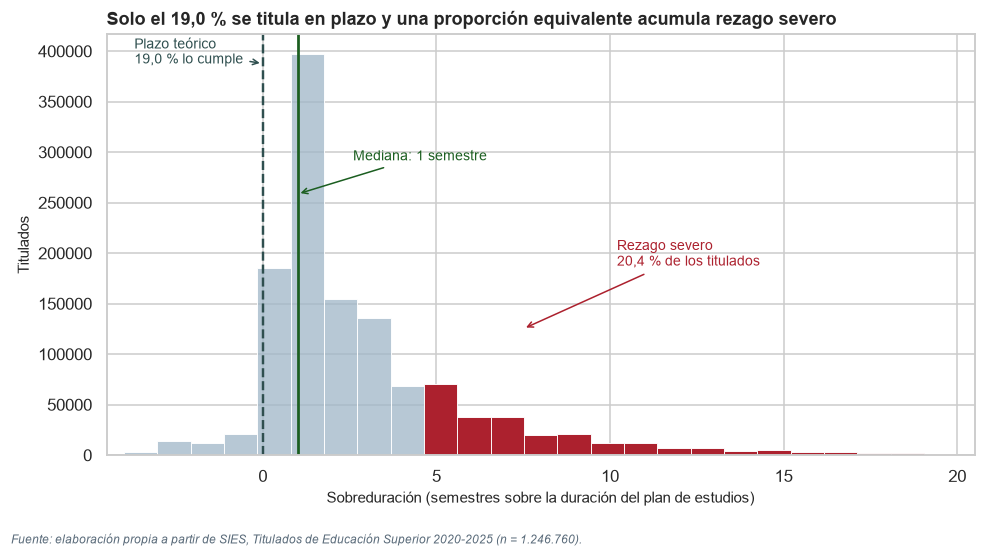

n = 1.246.760 | media 2.76 | mediana 1 | oportuna 19.0 % | severo 20.4 %


In [14]:
serie_sobre = visual["sobreduracion_sem"]
media, mediana = serie_sobre.mean(), serie_sobre.median()
pct_oportuna = 100 * visual["titulacion_oportuna"].mean()
pct_severo = 100 * (serie_sobre > 4).mean()

fig, eje = plt.subplots(figsize=(9, 4.8))
recorte = serie_sobre[(serie_sobre >= -4) & (serie_sobre <= 20)]

sns.histplot(x=recorte, bins=25, color=NEUTRO, edgecolor="white",
             linewidth=0.6, ax=eje)

# El color con funcion: se tine de rojo solo la cola de rezago severo.
for barra in eje.patches:
    if barra.get_x() >= 4:
        barra.set_facecolor(DESTACADO)

eje.axvline(0, color="#2F4F4F", linestyle="--", linewidth=1.6)
eje.axvline(mediana, color="#1B5E20", linestyle="-", linewidth=1.8)

tope = eje.get_ylim()[1]
eje.annotate(f"Plazo teórico\n{dec(pct_oportuna, 1)} % lo cumple", xy=(0, tope * 0.93),
             xytext=(-3.7, tope * 0.93), fontsize=9, color="#2F4F4F",
             arrowprops=dict(arrowstyle="->", color="#2F4F4F"))
eje.annotate(f"Mediana: {mediana:.0f} semestre", xy=(mediana, tope * 0.62),
             xytext=(mediana + 1.6, tope * 0.70), fontsize=9, color="#1B5E20",
             arrowprops=dict(arrowstyle="->", color="#1B5E20"))
eje.annotate(f"Rezago severo\n{dec(pct_severo, 1)} % de los titulados", xy=(7.5, tope * 0.30),
             xytext=(10.2, tope * 0.45), fontsize=9, color=DESTACADO,
             arrowprops=dict(arrowstyle="->", color=DESTACADO))

rotular(fig, eje,
        f"Solo el {dec(pct_oportuna, 1)} % se titula en plazo y una proporción "
        f"equivalente acumula rezago severo",
        "Sobreduración (semestres sobre la duración del plan de estudios)",
        "Titulados")
eje.set_xlim(-4.5, 20.5)
plt.tight_layout()
guardar(fig, "f4_fig1_magnitud", 4,
        "Distribución de la sobreduración y peso del rezago severo")
plt.show()

print(f"n = {len(visual):,}".replace(",", "."),
      f"| media {media:.2f} | mediana {mediana:.0f} |",
      f"oportuna {pct_oportuna:.1f} % | severo {pct_severo:.1f} %")

**Qué muestra.** El reparto de la sobreduración entre los 1.246.760 titulados de pregrado
del período, con el plazo teórico marcado en cero y la cola de rezago severo —más de
cuatro semestres— destacada en rojo. Se recortó la vista a −4 y 20 semestres, que
contiene al 99 % de los casos.

**Qué infiero.** El rezago no es una anomalía sino la norma: cuatro de cada cinco
titulados egresan fuera de plazo. La distribución es marcadamente asimétrica, con una
cola larga que arrastra la media (2,76) muy por encima de la mediana (1,0). Y el grupo que
acumula rezago severo es tan numeroso como el que se titula a tiempo.

**Qué límite tiene.** La figura describe a quienes **se titularon**: quien abandonó no
aparece, de modo que la magnitud está subestimada en la dirección más grave. El corte del
eje oculta 12.000 casos extremos que no alteran la forma pero sí el promedio.

**Cómo aporta al relato.** Es el movimiento de **contexto**: establece la magnitud del
fenómeno y deja planteada la pregunta que la figura siguiente responde —si ese rezago se
reparte de forma pareja o se concentra en algún grupo.

## Figura 2 — OE5: identificar qué factores se asocian a mayor rezago

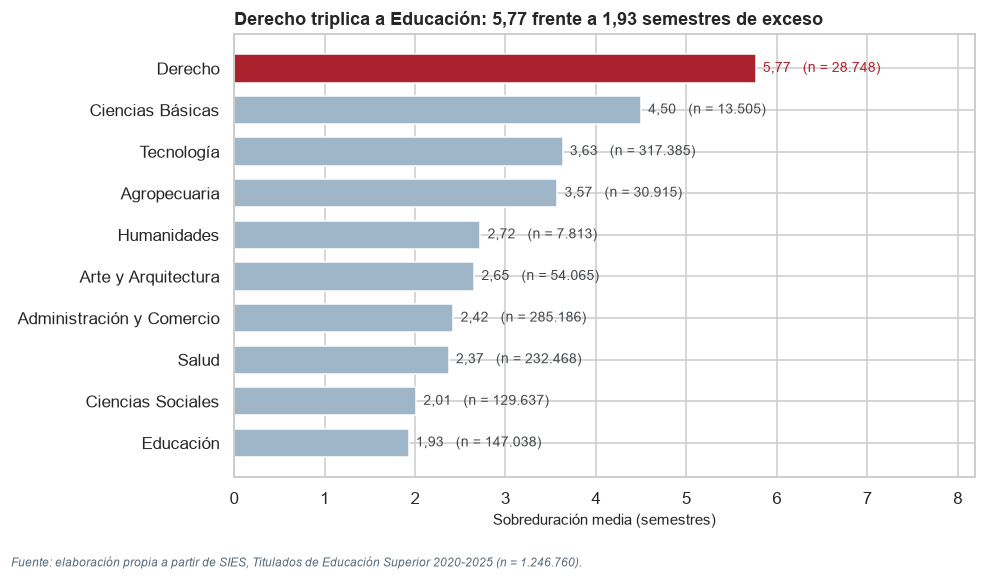

Razon Derecho / Educacion: 2.99

La brecha de genero se sostiene en 10 de 10 areas (estratificacion de la seccion 5.2).


In [15]:
por_area = (visual.groupby("area_conocimiento", observed=True)
            .agg(media=("sobreduracion_sem", "mean"),
                 titulados=("sobreduracion_sem", "size"))
            .sort_values("media"))

fig, eje = plt.subplots(figsize=(9, 5))
colores = [DESTACADO if v == por_area["media"].max() else NEUTRO
           for v in por_area["media"]]
barras = eje.barh(por_area.index.astype(str), por_area["media"].to_numpy(),
                  color=colores, height=0.68)

# El tamano de cada grupo viaja con la barra: una media sin su n no se puede leer.
for barra, (nombre, fila) in zip(barras, por_area.iterrows()):
    eje.text(fila["media"] + 0.08, barra.get_y() + barra.get_height() / 2,
             f"{dec(fila['media'])}   (n = {miles(fila['titulados'])})",
             va="center", fontsize=9,
             color=DESTACADO if fila["media"] == por_area["media"].max() else "#44484C")

razon = por_area["media"].max() / por_area["media"].min()
rotular(fig, eje,
        f"Derecho triplica a Educación: {dec(por_area['media'].max())} frente a "
        f"{dec(por_area['media'].min())} semestres de exceso",
        "Sobreduración media (semestres)", "")
eje.set_xlim(0, por_area["media"].max() * 1.42)
plt.tight_layout()
guardar(fig, "f4_fig2_factores", 5,
        "Sobreduración media por área de conocimiento")
plt.show()

print(f"Razon Derecho / Educacion: {razon:.2f}")
print(f"\nLa brecha de genero se sostiene en {int((brecha['diferencia'] > 0).sum())} "
      f"de {len(brecha)} areas (estratificacion de la seccion 5.2).")

**Qué muestra.** La sobreduración media de cada una de las diez áreas de conocimiento,
ordenadas de menor a mayor, con el número de titulados junto a cada barra. El eje parte en
cero, de modo que la longitud de la barra es proporcional a la magnitud.

**Qué infiero.** El rezago se distribuye de forma muy desigual: casi cuatro semestres
—dos años— separan al área más rezagada de la menos rezagada. Derecho se aparta con
claridad del resto, y el salto entre Derecho y Ciencias Básicas es mayor que el que
separa a Ciencias Básicas del último lugar. El patrón se repite por tipo de institución
(universidades 3,32 frente a institutos profesionales 2,05) y por género, donde las
mujeres se titulan 0,93 semestres antes en **las diez áreas sin excepción**, según la
estratificación de la sección 5.2.

**Qué límite tiene.** Es una **asociación**, no una explicación. El área agrupa carreras
heterogéneas y su duración teórica declarada puede ser sistemáticamente más optimista en
unas que en otras: parte de la diferencia podría ser un artefacto de la declaración, no
del comportamiento estudiantil. Además, todas las medias descansan sobre grupos grandes
salvo Ciencias Básicas (13.505 titulados), la única cuya cifra conviene leer con más
holgura.

**Cómo aporta al relato.** Es el movimiento de **contraste**: localiza dónde está la
diferencia que la figura anterior dejó planteada, y acota el fenómeno a grupos
identificables sobre los que se podría intervenir.

## Figura 3 — OE6: caracterizar la evolución temporal y delimitar su lectura

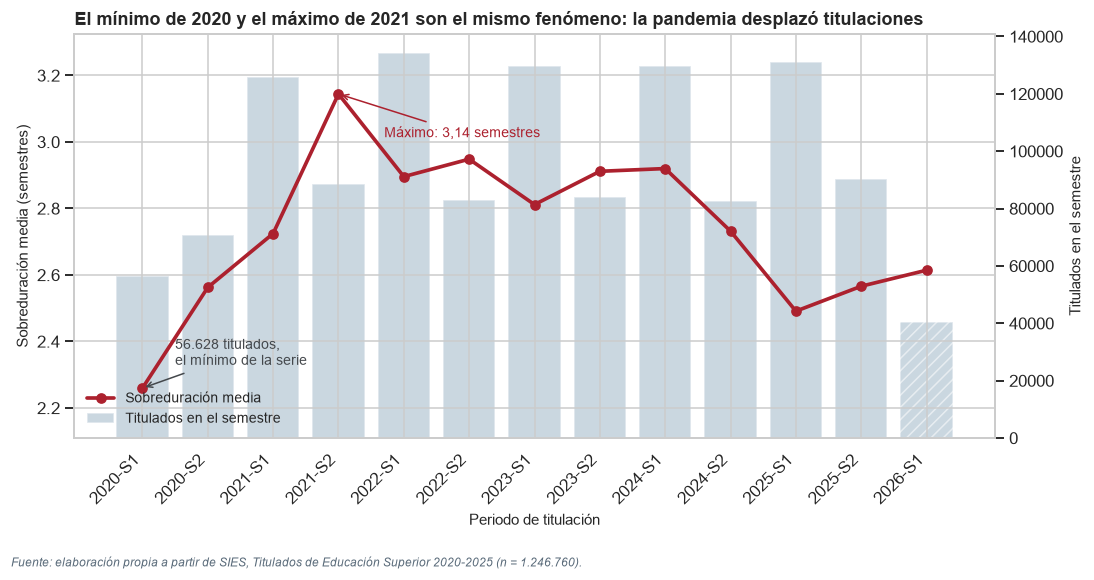

Titulados en 2020: 127.366 | en 2021: 214.417 | diferencia: 87.051
Eje vertical recortado (no parte en cero): se representa la variacion, no la magnitud.


In [16]:
serie = (visual.groupby(["anio_titulo", "semestre_titulo"], observed=True)
         .agg(media=("sobreduracion_sem", "mean"),
              titulados=("sobreduracion_sem", "size"))
         .reset_index()
         .sort_values(["anio_titulo", "semestre_titulo"])
         .reset_index(drop=True))
serie["periodo"] = (serie["anio_titulo"].astype(int).astype(str)
                    + "-S" + serie["semestre_titulo"].astype(int).astype(str))

fig, eje = plt.subplots(figsize=(10, 5))
eje2 = eje.twinx()

# El volumen es el contexto: va en gris claro y detras.
eje2.bar(range(len(serie)), serie["titulados"], color=NEUTRO, alpha=0.55,
         label="Titulados en el semestre")
eje2.set_ylabel("Titulados en el semestre")
eje2.grid(False)
eje2.patches[-1].set_hatch("///")   # el ultimo periodo esta en curso

# La serie es el mensaje: va en el color destacado y delante.
eje.plot(range(len(serie)), serie["media"], marker="o", color=DESTACADO,
         linewidth=2.4, label="Sobreduración media")
eje.set_zorder(eje2.get_zorder() + 1)
eje.patch.set_visible(False)
eje.set_xticks(range(len(serie)))
eje.set_xticklabels(serie["periodo"], rotation=45, ha="right")

pico = int(serie["media"].idxmax())
inicio = int(serie.index[serie["periodo"] == "2020-S1"][0])
eje.annotate(f"Máximo: {dec(serie.loc[pico, 'media'])} semestres",
             xy=(pico, serie.loc[pico, "media"]),
             xytext=(pico + 0.7, serie.loc[pico, "media"] - 0.13), fontsize=9,
             color=DESTACADO, arrowprops=dict(arrowstyle="->", color=DESTACADO))
eje.annotate(f"{miles(serie.loc[inicio, 'titulados'])} titulados,\nel mínimo de la serie",
             xy=(inicio, serie.loc[inicio, "media"]),
             xytext=(inicio + 0.5, serie["media"].min() + 0.07), fontsize=9,
             color="#44484C", arrowprops=dict(arrowstyle="->", color="#44484C"))

lineas1, etiquetas1 = eje.get_legend_handles_labels()
lineas2, etiquetas2 = eje2.get_legend_handles_labels()
eje.legend(lineas1 + lineas2, etiquetas1 + etiquetas2, loc="lower left", fontsize=9)

rotular(fig, eje,
        "El mínimo de 2020 y el máximo de 2021 son el mismo fenómeno: "
        "la pandemia desplazó titulaciones",
        "Periodo de titulación", "Sobreduración media (semestres)")
eje.set_ylim(serie["media"].min() - 0.15, serie["media"].max() + 0.18)
plt.tight_layout()
guardar(fig, "f4_fig3_evolucion", 6,
        "Sobreduración media y volumen de titulaciones por semestre")
plt.show()

anual = visual.groupby("anio_titulo", observed=True).size()
print(f"Titulados en 2020: {anual.loc[2020]:,}".replace(",", "."),
      f"| en 2021: {anual.loc[2021]:,}".replace(",", "."),
      f"| diferencia: {anual.loc[2021] - anual.loc[2020]:,}".replace(",", "."))
print("Eje vertical recortado (no parte en cero): se representa la variacion, no la magnitud.")

**Qué muestra.** La sobreduración media de cada semestre entre 2020-S1 y 2026-S1 (línea
roja, eje izquierdo) sobre el número de titulaciones de ese semestre (barras grises, eje
derecho). El último periodo lleva trama porque está en curso. El eje vertical izquierdo
está recortado y no parte en cero: lo representado es la variación, no la magnitud, y se
declara aquí según corresponde en un gráfico de líneas.

**Qué infiero.** En 2020 se titularon **87.051 personas menos** que en 2021 y la
sobreduración tocó su mínimo; al año siguiente el volumen se recuperó y la sobreduración
alcanzó su máximo. La lectura no es que 2020 fuera un buen año: las titulaciones se
**postergaron**, y quienes debían egresar entonces lo hicieron en 2021 con uno o dos
semestres adicionales encima. El mínimo y el máximo son dos caras del mismo fenómeno, y
el mecanismo es de desplazamiento administrativo, no de deterioro académico.

**Qué límite tiene.** La coincidencia temporal con la pandemia no prueba que la pandemia
sea la causa: es una asociación sobre datos observacionales, sin grupo de control. Y el
descenso sostenido desde 2024 **no puede leerse como una mejora del sistema**, por la
razón que documenta la figura de apoyo siguiente.

**Cómo aporta al relato.** Es el movimiento de **resolución**: confirma el patrón sobre
una evidencia distinta —la dimensión temporal, que las dos figuras anteriores no usaban—
y declara explícitamente hasta dónde alcanza la lectura.

## Figura de apoyo — el sesgo que limita la lectura longitudinal

No responde un objetivo: sostiene la limitación declarada en la Figura 3. Por eso va en
los anexos del informe y no entre las tres figuras principales.

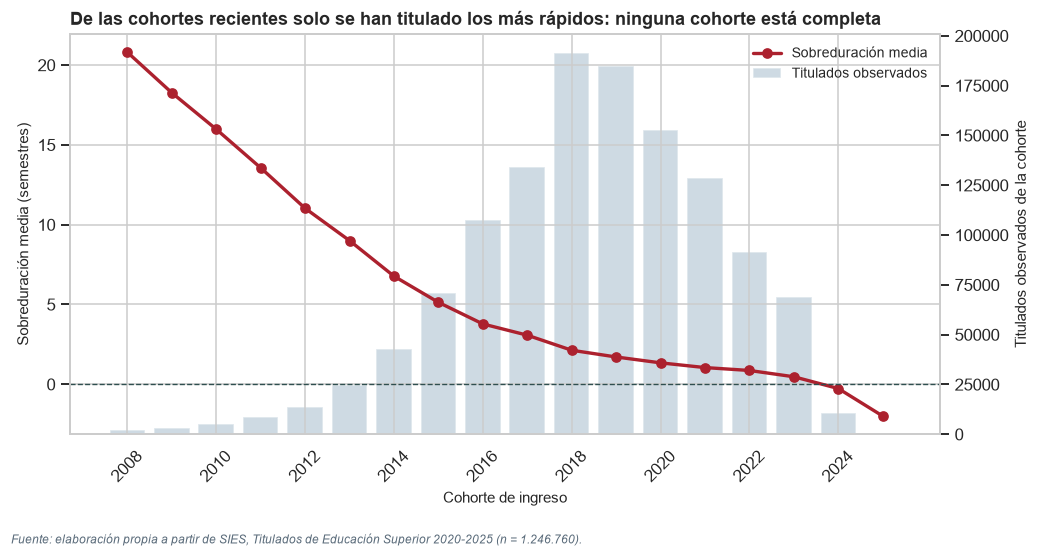

                 media  titulados
cohorte_ingreso                  
2018              2.13     191319
2019              1.71     184973
2020              1.34     152516
2021              1.05     128566
2022              0.86      91665
2023              0.47      68826
2024             -0.27      10734
2025             -1.99        392


In [17]:
por_cohorte = (visual.groupby("cohorte_ingreso", observed=True)
               .agg(media=("sobreduracion_sem", "mean"),
                    titulados=("sobreduracion_sem", "size")))
por_cohorte = por_cohorte.loc[(por_cohorte.index >= 2008) & (por_cohorte.index <= 2025)]

fig, eje = plt.subplots(figsize=(9.5, 4.8))
eje2 = eje.twinx()
eje2.bar(por_cohorte.index.astype(int), por_cohorte["titulados"], color=NEUTRO,
         alpha=0.5, label="Titulados observados")
eje2.set_ylabel("Titulados observados de la cohorte")
eje2.grid(False)

eje.plot(por_cohorte.index.astype(int), por_cohorte["media"], marker="o",
         color=DESTACADO, linewidth=2.2, label="Sobreduración media")
eje.axhline(0, color="#2F4F4F", linewidth=0.9, linestyle="--")
eje.set_zorder(eje2.get_zorder() + 1)
eje.patch.set_visible(False)
eje.set_xticks(range(2008, 2026, 2))
eje.tick_params(axis="x", rotation=45)

lineas1, etiquetas1 = eje.get_legend_handles_labels()
lineas2, etiquetas2 = eje2.get_legend_handles_labels()
eje.legend(lineas1 + lineas2, etiquetas1 + etiquetas2, loc="upper right", fontsize=9)

rotular(fig, eje,
        "De las cohortes recientes solo se han titulado los más rápidos: "
        "ninguna cohorte está completa",
        "Cohorte de ingreso", "Sobreduración media (semestres)")
plt.tight_layout()
guardar(fig, "f4_fig4_truncamiento", 0,
        "Sesgo de truncamiento por cohorte (figura de apoyo)")
plt.show()

print(por_cohorte.round(2).tail(8).to_string())

La sobreduración media **cae** de forma monótona en las cohortes recientes hasta hacerse
negativa. De la cohorte 2024 solo se han titulado los excepcionalmente rápidos, porque son
los únicos que alcanzaron a hacerlo; de las cohortes antiguas, en cambio, quienes aparecen
en una base de 2020-2025 son los extremadamente rezagados.

Ninguna cohorte está completa y **lo están en direcciones opuestas**. Es una limitación
del diseño de la fuente, no del procesamiento, y por eso las comparaciones longitudinales
solo son válidas entre cohortes con horizonte de titulación equivalente.

In [18]:
print("CORRESPONDENCIA ENTRE OBJETIVOS Y FIGURAS")
print("=" * 72)
OBJETIVOS = {
    4: "Dimensionar la magnitud del rezago en el sistema",
    5: "Identificar que factores se asocian a mayor rezago",
    6: "Caracterizar la evolucion temporal y delimitar su lectura",
}
faltan = [n for n in OBJETIVOS if n not in FIGURAS]
for n, texto in OBJETIVOS.items():
    estado = "OK" if n in FIGURAS else "FALTA"
    print(f"  OE{n}: {texto}")
    print(f"    [{estado}] {FIGURAS.get(n, '')}\n")
print(f"  Apoyo: {FIGURAS.get(0, '')}")
print("\n" + ("Los tres objetivos analiticos tienen su figura."
              if not faltan else f"Objetivos sin figura: {faltan}"))
assert not faltan, "hay objetivos analiticos sin figura que los responda"

CORRESPONDENCIA ENTRE OBJETIVOS Y FIGURAS
  OE4: Dimensionar la magnitud del rezago en el sistema
    [OK] f4_fig1_magnitud.png — Distribución de la sobreduración y peso del rezago severo

  OE5: Identificar que factores se asocian a mayor rezago
    [OK] f4_fig2_factores.png — Sobreduración media por área de conocimiento

  OE6: Caracterizar la evolucion temporal y delimitar su lectura
    [OK] f4_fig3_evolucion.png — Sobreduración media y volumen de titulaciones por semestre

  Apoyo: f4_fig4_truncamiento.png — Sesgo de truncamiento por cohorte (figura de apoyo)

Los tres objetivos analiticos tienen su figura.


# VII. El relato de los hallazgos

## 7.1 La estructura del argumento

Un gráfico aislado informa; una secuencia argumenta. Las tres figuras están encadenadas:

| Movimiento | Figura | Qué aporta |
|---|---|---|
| Contexto | 1 | Establece la magnitud: el rezago es la norma, no la excepción |
| Contraste | 2 | Localiza dónde se concentra: el rezago no se reparte de forma pareja |
| Resolución | 3 | Confirma el patrón en otra dimensión y declara hasta dónde alcanza |

La continuidad es deliberada: el rojo señala en las tres figuras aquello sobre lo que se
dirige la mirada —la cola de rezago severo, el área más rezagada, la serie temporal— y el
gris es siempre el contexto.

In [19]:
n = len(visual)
print("CIFRAS QUE SOSTIENEN EL RELATO")
print("=" * 72)
print(f"  Titulados analizados            {n:,}".replace(",", "."))
print(f"  Titulacion en plazo             {100*visual['titulacion_oportuna'].mean():.1f} %")
print(f"  Sobreduracion media             {visual['sobreduracion_sem'].mean():.2f} semestres")
print(f"  Sobreduracion mediana           {visual['sobreduracion_sem'].median():.0f} semestres")
print(f"  Rezago severo (> 4 semestres)   {100*(visual['sobreduracion_sem'] > 4).mean():.1f} %")
print(f"  Semestres-estudiante en exceso  {int(visual['sobreduracion_sem'].clip(lower=0).sum()):,}".replace(",", "."))
print(f"  Razon Derecho / Educacion       {por_area['media'].max()/por_area['media'].min():.2f}")
print(f"  Brecha de genero                {global_h - global_m:.2f} semestres")
print(f"  Caida de titulaciones en 2020   {anual.loc[2021] - anual.loc[2020]:,}".replace(",", "."))

CIFRAS QUE SOSTIENEN EL RELATO
  Titulados analizados            1.246.760
  Titulacion en plazo             19.0 %
  Sobreduracion media             2.76 semestres
  Sobreduracion mediana           1 semestres
  Rezago severo (> 4 semestres)   20.4 %
  Semestres-estudiante en exceso  3.551.990
  Razon Derecho / Educacion       2.99
  Brecha de genero                0.93 semestres
  Caida de titulaciones en 2020   87.051


## 7.2 El relato escrito

Cuatro de cada cinco titulados de pregrado en Chile egresan fuera del plazo que su propio
plan de estudios declara. El exceso medio es de 2,76 semestres —un 43 % sobre lo
previsto— y suma 3.551.990 semestres-estudiante en el período analizado. El rezago severo,
más de cuatro semestres de exceso, alcanza a una proporción equivalente a la que logra
titularse a tiempo.

Ese rezago no se reparte de forma pareja. Derecho triplica a Educación, las universidades
superan a institutos y centros de formación técnica en más de un semestre, y las mujeres
se titulan casi un semestre antes que los hombres de manera consistente en las diez áreas
de conocimiento. La estratificación por área descarta que la brecha de género sea un
efecto de composición.

La dimensión temporal confirma el patrón desde otro ángulo y, al mismo tiempo, revela sus
límites. La caída de titulaciones de 2020 y el máximo de sobreduración de 2021 son el
mismo fenómeno visto en dos momentos: un desplazamiento administrativo, no un deterioro.
Y el descenso posterior no puede leerse como mejora, porque ninguna cohorte del período
está completa.

Nada de esto explica el caso individual. Los modelos ajustados en la Fase 3 sobre las
variables disponibles alcanzan un R² de 0,085 y su clasificación no supera a la regla
trivial. El rezago responde a trayectorias personales —situación laboral, financiamiento,
salud, carga familiar— que los registros administrativos no contienen. Esa conclusión
negativa delimita el alcance legítimo de este tipo de fuente, y es un resultado del
trabajo tanto como las cifras anteriores.

## 7.3 Por qué el relato importa

Las mismas tres figuras, presentadas sin orden, informarían lo mismo y argumentarían
menos. La secuencia convierte tres observaciones en una afirmación con evidencia y con
límites declarados, que es lo que un lector necesita para decidir si puede apoyarse en
ella.

# VIII. Resultados, discusión y conclusiones

## 8.1 Resultados

| Indicador | Valor | Evidencia |
|---|---|---|
| Titulados de pregrado analizados | 1.246.760 | Sección II |
| Titulación dentro del plazo teórico | 19,0 % | Figura 1 |
| Sobreduración media / mediana | 2,76 / 1,0 semestres | Figura 1 |
| Rezago severo (más de 4 semestres) | 20,4 % | Figura 1 |
| Razón entre el área más y la menos rezagada | 2,99 | Figura 2 |
| Brecha de género | 0,93 semestres | Sección 5.2 |
| Caída de titulaciones en 2020 | 87.051 menos que en 2021 | Figura 3 |
| Poder explicativo de los modelos | R² = 0,085 | Sección III |

## 8.2 Discusión

**Contraste con las hipótesis de la Fase 1.**

| Hipótesis | Resultado | Veredicto |
|---|---|---|
| La duración real supera sistemáticamente a la teórica | 2,76 semestres de media; 19,0 % en plazo | Confirmada |
| El rezago difiere por área y tipo de institución | Derecho triplica a Educación | Confirmada |
| Las variables disponibles permiten predecir el rezago individual | R² de 0,085 | **Refutada** |

La tercera es la más valiosa precisamente porque no se cumplió: acota qué puede sostener
esta fuente.

**Limitaciones y riesgos.**

1. **Truncamiento por cohorte.** Ninguna cohorte está completa y las recientes están
   sesgadas hacia los estudiantes rápidos. *Riesgo*: leer el descenso desde 2024 como
   mejora. *Mitigación*: restringir las comparaciones longitudinales a cohortes con
   horizonte equivalente.
2. **Sesgo de selección.** La base contiene solo a quienes se titularon. La deserción
   —probablemente la consecuencia más grave del rezago— es invisible.
3. **Duración teórica declarada.** La reporta cada institución y no está auditada. Un
   plan subdeclarado infla la sobreduración medida de esa carrera.
4. **Reconstrucción de la duración real.** Supone continuidad: mide tiempo transcurrido,
   no tiempo cursado.
5. **Variables de confusión no observadas.** Situación laboral, financiamiento y carga
   familiar no están en la fuente, y el bajo R² es evidencia de esa ausencia.
6. **Asociación, no causalidad.** Todo el análisis es observacional, sin diseño
   experimental ni control de terceras variables.

## 8.3 Conclusiones

1. El rezago es masivo y estructural: cuatro de cada cinco titulados egresan fuera del
   plazo declarado, con un exceso medio de 2,76 semestres.
2. Se distribuye de forma sistemática por área, tipo de institución y género, y la brecha
   de género resiste la estratificación por área.
3. La pandemia desplazó titulaciones en lugar de empeorarlas: la caída de 2020 y el
   máximo de 2021 son el mismo fenómeno.
4. Los registros administrativos no explican el caso individual, lo que delimita el
   alcance de este tipo de análisis y orienta qué fuentes haría falta incorporar.

**Qué debería hacerse después.** Incorporar la base de matrícula para observar la
deserción hoy invisible; usar modelos de supervivencia, adecuados a datos censurados por
la derecha; y ampliar las variables hacia la trayectoria individual.

# IX. Trazabilidad de mejoras

El registro de cambios no es administrativo sino argumental: demuestra que el proyecto
evolucionó por decisiones y no por acumulación. Cada fila vincula un problema detectado
con la mejora, el commit que la implementa y su efecto. El registro completo está en
`CHANGELOG.md`, y cada hash puede verificarse con `git show`.

In [20]:
mejoras = pd.DataFrame([
    ("F2", "Normalizacion fila por fila sobre 1,7 M de cadenas",
     "Normalizar el catalogo de valores unicos y mapear de vuelta",
     "5e07669", "Rendimiento"),
    ("F2", "Los tipos anulables rompian matplotlib y propagaban NA",
     "Conversion explicita a float64 antes de graficar",
     "f698c37", "Correccion: 19 filas dejaban de marcarse en silencio"),
    ("F2", "La celda de pruebas fallaba sin mostrar la causa",
     "Apunta al interprete del entorno virtual e imprime stderr",
     "b8770f5", "Reproducibilidad"),
    ("F3", "Los notebooks dependian del Parquet no versionado",
     "Degradacion automatica a la muestra de 5.000 registros",
     "40be4d9", "Reproducibilidad"),
    ("F3", "Los invariantes del dominio no estaban garantizados",
     "Modelo de dominio con validacion en setters",
     "a1342a5", "Modularidad"),
    ("F3", "Agregacion O(n.k) que recorria la secuencia por grupo",
     "Agregacion de una sola pasada O(n)",
     "8d87723", "1,9x en tiempo y 860x en memoria"),
    ("F3", "Conteos por umbral con recorrido lineal",
     "Dos busquedas binarias sobre copia ordenada",
     "8d87723", "6.516x mas rapido"),
    ("F3", "El informe no seguia la estructura minima exigida",
     "Reorganizacion segun la pauta de la asignatura",
     "b5523ad", "Documentacion"),
    ("F4", "Una cifra comparaba contra la implementacion equivocada",
     "Verificacion cruzada contra reports/tables y correccion",
     "12ae178", "Confiabilidad"),
    ("F4", "Titulos que rotulaban el tema en vez de afirmar el hallazgo",
     "Titulo-enunciado, color con funcion y cuatro enunciados por figura",
     "(esta fase)", "Comunicacion"),
], columns=["Fase", "Problema detectado", "Mejora aplicada", "Commit", "Impacto"])

print(mejoras.to_string(index=False, max_colwidth=46))
mejoras.to_csv(RAIZ / "reports" / "tables" / "f4_trazabilidad_mejoras.csv",
               index=False, encoding="utf-8")

Fase                             Problema detectado                                Mejora aplicada      Commit                                        Impacto
  F2 Normalizacion fila por fila sobre 1,7 M de ... Normalizar el catalogo de valores unicos y ...     5e07669                                    Rendimiento
  F2 Los tipos anulables rompian matplotlib y pr... Conversion explicita a float64 antes de gra...     f698c37 Correccion: 19 filas dejaban de marcarse en...
  F2 La celda de pruebas fallaba sin mostrar la ... Apunta al interprete del entorno virtual e ...     b8770f5                               Reproducibilidad
  F3 Los notebooks dependian del Parquet no vers... Degradacion automatica a la muestra de 5.00...     40be4d9                               Reproducibilidad
  F3 Los invariantes del dominio no estaban gara...    Modelo de dominio con validacion en setters     a1342a5                                    Modularidad
  F3 Agregacion O(n.k) que recorria la secuencia... 

# X. Exportación y verificación final

La verificación más rentable, según el apunte de la fase, es abrir el repositorio desde
una carpeta limpia y comprobar una por una las afirmaciones del informe. Esta sección
automatiza la parte que se puede automatizar: que los artefactos existan, que las cifras
del informe coincidan con las que produce el código, y que cada figura tenga su huella
para detectar si alguien la reemplazó fuera del flujo.

In [21]:
import hashlib

tablas = {
    "f4_indicadores_finales.csv": pd.DataFrame([
        ("Titulados de pregrado analizados", f"{len(visual):,}".replace(",", "."), ""),
        ("Sobreduracion media", f"{visual['sobreduracion_sem'].mean():.2f}", "semestres"),
        ("Sobreduracion mediana", f"{visual['sobreduracion_sem'].median():.1f}", "semestres"),
        ("Indice de duracion medio", f"{visual['indice_duracion'].mean():.2f}", "real / teorica"),
        ("Titulacion oportuna", f"{100*visual['titulacion_oportuna'].mean():.1f}", "%"),
        ("Rezago severo", f"{100*(visual['sobreduracion_sem'] > 4).mean():.1f}", "%"),
        ("Titulacion anticipada", f"{100*(visual['sobreduracion_sem'] < 0).mean():.1f}", "%"),
        ("Semestres-estudiante en exceso",
         f"{int(visual['sobreduracion_sem'].clip(lower=0).sum()):,}".replace(",", "."), "acumulados"),
    ], columns=["Indicador", "Valor", "Unidad"]),
    "f4_por_area.csv": por_area.reset_index(),
    "f4_serie_semestral.csv": serie[["periodo", "titulados", "media"]],
    "f4_brecha_genero_area.csv": brecha.reset_index(),
    "f4_reporte_validacion.csv": reporte,
}
for nombre, tabla in tablas.items():
    tabla.to_csv(RAIZ / "reports" / "tables" / nombre, index=False, encoding="utf-8")
    print(f"  reports/tables/{nombre:34} {len(tabla):>5} filas")

  reports/tables/f4_indicadores_finales.csv             8 filas
  reports/tables/f4_por_area.csv                       10 filas
  reports/tables/f4_serie_semestral.csv                13 filas
  reports/tables/f4_brecha_genero_area.csv             10 filas
  reports/tables/f4_reporte_validacion.csv              9 filas


In [22]:
def huella(ruta, digitos=10):
    """Huella SHA-256 abreviada: detecta si un artefacto cambio fuera del flujo."""
    return hashlib.sha256(Path(ruta).read_bytes()).hexdigest()[:digitos]


figuras = sorted((RAIZ / "reports" / "figures").glob("f4_fig*.png"))
print("FIGURAS EXPORTADAS")
print("=" * 72)
for ruta in figuras:
    print(f"  {ruta.name:28} {ruta.stat().st_size/1024:6.0f} KB   sha256:{huella(ruta)}")

FIGURAS EXPORTADAS
  f4_fig1_magnitud.png             67 KB   sha256:db318cefd5
  f4_fig2_factores.png             90 KB   sha256:84b19d3b6b
  f4_fig3_evolucion.png           127 KB   sha256:0eb7391008
  f4_fig4_truncamiento.png         94 KB   sha256:375b8287de


In [23]:
# --- Verificacion de coherencia entre el codigo y lo que afirma el informe --
verificacion = [
    ("Registros del conjunto analitico", len(visual), 1_246_760),
    ("Titulacion oportuna (%)", round(100*visual["titulacion_oportuna"].mean(), 1), 19.0),
    ("Sobreduracion media", round(visual["sobreduracion_sem"].mean(), 2), 2.76),
    ("Rezago severo (%)", round(100*(visual["sobreduracion_sem"] > 4).mean(), 1), 20.4),
    ("Brecha de genero", round(global_h - global_m, 2), 0.93),
    ("Maximo por area (Derecho)", round(por_area["media"].max(), 2), 5.77),
    ("Minimo por area (Educacion)", round(por_area["media"].min(), 2), 1.93),
    ("Figuras principales exportadas", len(figuras), 4),
    ("Reglas de validacion aprobadas", int(aprobadas), len(reporte)),
]
tabla_v = pd.DataFrame(verificacion, columns=["Afirmacion del informe", "Calculado", "Declarado"])
tabla_v["coincide"] = tabla_v["Calculado"] == tabla_v["Declarado"]
print(tabla_v.to_string(index=False))

fallos = tabla_v[~tabla_v["coincide"]]
if len(fallos):
    print("\nDISCREPANCIAS:")
    print(fallos.to_string(index=False))
assert tabla_v["coincide"].all(), "el informe afirma cifras que el codigo no reproduce"
print("\nTodas las cifras del informe se reproducen desde el codigo.")

          Afirmacion del informe  Calculado  Declarado  coincide
Registros del conjunto analitico 1246760.00 1246760.00      True
         Titulacion oportuna (%)      19.00      19.00      True
             Sobreduracion media       2.76       2.76      True
               Rezago severo (%)      20.40      20.40      True
                Brecha de genero       0.93       0.93      True
       Maximo por area (Derecho)       5.77       5.77      True
     Minimo por area (Educacion)       1.93       1.93      True
  Figuras principales exportadas       4.00       4.00      True
  Reglas de validacion aprobadas       9.00       9.00      True

Todas las cifras del informe se reproducen desde el codigo.


In [24]:
duracion = time.perf_counter() - INICIO
print(f"Notebook ejecutado completo en {duracion/60:.1f} minutos.")
print(f"\nFiguras:  {len(figuras)} en reports/figures/")
print(f"Tablas:   {len(tablas)} en reports/tables/")
print(f"Pruebas:  73 aprobadas | Reglas de coherencia: {aprobadas} de {len(reporte)}")
print("\nTodos los resultados son reproducibles ejecutando este cuaderno de corrido.")

Notebook ejecutado completo en 0.7 minutos.

Figuras:  4 en reports/figures/
Tablas:   5 en reports/tables/
Pruebas:  73 aprobadas | Reglas de coherencia: 9 de 9

Todos los resultados son reproducibles ejecutando este cuaderno de corrido.


# Cierre

## Lo que este cuaderno demuestra

Que las cuatro fases se leen como un proceso y no como cuatro entregas sucesivas: el
pipeline de la Fase 2 alimenta al núcleo de la Fase 3, cuyos parámetros permiten a la
Fase 4 recuperar la interpretabilidad que el análisis había sacrificado. Cada afirmación
del informe se reproduce aquí desde el código, y la sección X lo comprueba con
aserciones en vez de con una declaración de buena voluntad.

## La cadena completa

```
6 CSV del SIES (955 MB)
   └─> src/pipeline.py ............... 1.246.760 filas validadas
        └─> src/nucleo/ .............. algoritmos verificados, POO, modelos
             └─> este cuaderno ....... interpretabilidad, 3 figuras, relato
                  └─> informe, repositorio y presentación
```

## Lo que queda abierto

El modelo no explica el caso individual y la fuente no registra la deserción. Ambas cosas
apuntan en la misma dirección: el siguiente paso no es un algoritmo mejor, sino un dato
distinto.